# HW13 – токенизация, инференс pretrained BERT и fine-tuning для классификации текста

В этом ноутбуке последовательно разбираем учебный pipeline для текстовой классификации:

1. загружаем датасет;
2. делаем sanity-check по данным;
3. показываем токенизацию нескольких текстов;
4. запускаем инференс готовой pretrained-модели;
5. делаем fine-tuning BERT-подобной модели для sequence classification;
6. оцениваем качество на validation и test;
7. сохраняем обязательные артефакты в `artifacts/`.

In [1]:
# Базовые библиотеки для воспроизводимости, анализа, визуализации и обучения.
import os
import random
from pathlib import Path
from typing import List, Dict, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

from datasets import load_dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    pipeline,
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

In [2]:
# Фиксируем seed и определяем устройство.
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("torch:", torch.__version__)

device: cpu
torch: 2.10.0+cpu


In [3]:
# Пути проекта и папка артефактов.
ROOT_DIR = Path(".")
ARTIFACTS_DIR = ROOT_DIR / "artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT_DIR:", ROOT_DIR.resolve())
print("ARTIFACTS_DIR:", ARTIFACTS_DIR.resolve())

ROOT_DIR: C:\Users\Anna\OneDrive\Desktop\courses\Ix3_course\homeworks\HW13
ARTIFACTS_DIR: C:\Users\Anna\OneDrive\Desktop\courses\Ix3_course\homeworks\HW13\artifacts


## 1. Датасет и первичный анализ

Для домашней работы берём датасет `emotion`.

Это задача многоклассовой классификации коротких текстов по эмоциональной метке.
Наша цель — по тексту предсказать, к какой эмоции он относится.

In [4]:
# Загружаем датасет emotion.
dataset = load_dataset("emotion")
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [5]:
# Показываем размеры split-частей.
for split_name in dataset.keys():
    print(f"{split_name}: {len(dataset[split_name])}")

train: 16000
validation: 2000
test: 2000


In [6]:
# Названия классов.
label_feature = dataset["train"].features["label"]
label_names = label_feature.names

print("label_names:", label_names)
print("num_classes:", len(label_names))

label_names: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
num_classes: 6


In [7]:
# Несколько примеров текстов и меток.
sample_df = pd.DataFrame(dataset["train"][:5])
sample_df["label_name"] = sample_df["label"].map(lambda x: label_names[x])
sample_df

,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


In [8]:
# Распределение классов в train.
train_df_preview = pd.DataFrame(dataset["train"][:])
train_df_preview["label_name"] = train_df_preview["label"].map(lambda x: label_names[x])

display(train_df_preview["label_name"].value_counts())

label_name
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64

Краткий комментарий:

- объект классификации: короткий текст;
- целевая переменная: эмоциональная метка;
- классы: несколько фиксированных эмоций;
- задача: по тексту определить наиболее вероятную эмоцию.

## 2. Токенизация: как текст превращается во вход модели

Трансформер не получает на вход "сырую" строку напрямую.
Сначала текст проходит через токенизатор:

`текст -> токены -> input_ids -> attention_mask -> вход модели`

Ниже компактно покажем это на нескольких примерах.

In [9]:
# Модель и токенизатор для дальнейшей работы.
MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("Tokenizer loaded:", tokenizer.__class__.__name__)
print("Model checkpoint:", MODEL_NAME)

Tokenizer loaded: BertTokenizer
Model checkpoint: distilbert-base-uncased


In [10]:
# Несколько примеров для разбора токенизации.
tokenization_texts = [
    dataset["train"][0]["text"],
    dataset["train"][1]["text"],
    dataset["train"][2]["text"],
    "I am extremely happy today because everything worked perfectly.",
    "I feel terrible, tired, and completely disappointed in the result.",
]

tokenization_texts

['i didnt feel humiliated',
 'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake',
 'im grabbing a minute to post i feel greedy wrong',
 'I am extremely happy today because everything worked perfectly.',
 'I feel terrible, tired, and completely disappointed in the result.']

In [11]:
# Удобная функция для компактного просмотра токенизации одного текста.
def inspect_single_text(text: str, tokenizer) -> pd.DataFrame:
    encoded = tokenizer(
        text,
        add_special_tokens=True,
        truncation=True,
        max_length=32,
    )

    tokens = tokenizer.convert_ids_to_tokens(encoded["input_ids"])

    return pd.DataFrame(
        {
            "token": tokens,
            "input_id": encoded["input_ids"],
            "attention_mask": encoded["attention_mask"],
        }
    )

inspect_single_text(tokenization_texts[0], tokenizer)

,token,input_id,attention_mask
0,[CLS],101,1
1,i,1045,1
2,didn,2134,1
3,##t,2102,1
4,feel,2514,1
5,humiliated,26608,1
6,[SEP],102,1


In [12]:
# Покажем 3 примера.
for i, text in enumerate(tokenization_texts[:3], start=1):
    print("=" * 100)
    print(f"EXAMPLE {i}")
    print("TEXT:", text)
    display(inspect_single_text(text, tokenizer))

EXAMPLE 1
TEXT: i didnt feel humiliated


,token,input_id,attention_mask
0,[CLS],101,1
1,i,1045,1
2,didn,2134,1
3,##t,2102,1
4,feel,2514,1
5,humiliated,26608,1
6,[SEP],102,1


EXAMPLE 2
TEXT: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake


,token,input_id,attention_mask
0,[CLS],101,1
1,i,1045,1
2,can,2064,1
3,go,2175,1
4,from,2013,1
5,feeling,3110,1
6,so,2061,1
7,hopeless,20625,1
8,to,2000,1
9,so,2061,1


EXAMPLE 3
TEXT: im grabbing a minute to post i feel greedy wrong


,token,input_id,attention_mask
0,[CLS],101,1
1,im,10047,1
2,grabbing,9775,1
3,a,1037,1
4,minute,3371,1
5,to,2000,1
6,post,2695,1
7,i,1045,1
8,feel,2514,1
9,greedy,20505,1


In [13]:
# Special tokens токенизатора.
special_tokens_df = pd.DataFrame(
    {
        "name": [
            "cls_token",
            "sep_token",
            "pad_token",
            "unk_token",
            "mask_token",
        ],
        "value": [
            tokenizer.cls_token,
            tokenizer.sep_token,
            tokenizer.pad_token,
            tokenizer.unk_token,
            tokenizer.mask_token,
        ],
        "id": [
            tokenizer.cls_token_id,
            tokenizer.sep_token_id,
            tokenizer.pad_token_id,
            tokenizer.unk_token_id,
            tokenizer.mask_token_id,
        ],
    }
)

special_tokens_df

,name,value,id
0,cls_token,[CLS],101
1,sep_token,[SEP],102
2,pad_token,[PAD],0
3,unk_token,[UNK],100
4,mask_token,[MASK],103


In [14]:
# Показываем padding и truncation.
short_text = "I feel good."
long_text = (
    "I am feeling overwhelmed because too many things happened at once and I do not "
    "know how to process everything that I experienced during this very long day."
)

batch = tokenizer(
    [short_text, long_text],
    padding=True,
    truncation=True,
    max_length=16,
)

batch_df = pd.DataFrame(
    {
        "text": [short_text, long_text],
        "input_ids": batch["input_ids"],
        "attention_mask": batch["attention_mask"],
        "decoded_tokens": [tokenizer.convert_ids_to_tokens(ids) for ids in batch["input_ids"]],
        "length": [len(ids) for ids in batch["input_ids"]],
    }
)

batch_df

,text,input_ids,attention_mask,decoded_tokens,length
0,I feel good.,"[101, 1045, 2514, 2204, 1012, 102, 0, 0, 0, 0,...","[1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[[CLS], i, feel, good, ., [SEP], [PAD], [PAD],...",16
1,I am feeling overwhelmed because too many thin...,"[101, 1045, 2572, 3110, 13394, 2138, 2205, 211...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]","[[CLS], i, am, feeling, overwhelmed, because, ...",16


Краткий вывод по токенизации:

- текст разбивается не на "слова", а на токены словаря модели;
- специальные токены добавляются автоматически;
- `input_ids` — это числовые идентификаторы токенов;
- `attention_mask` показывает, какие позиции настоящие, а какие являются padding;
- при `truncation=True` слишком длинные тексты обрезаются до `max_length`.

## 3. Инференс готовой pretrained-модели

Сначала покажем, как выглядит инференс "из коробки" на уже готовой модели классификации текста.

Важно:
эта pretrained-модель обучалась не на датасете `emotion`, а на другой задаче.
Поэтому здесь нас интересует не совпадение меток один в один,
а сам принцип работы готового инференса.

In [15]:
# Готовая pretrained-модель для sentiment classification.
PRETRAINED_INFERENCE_MODEL = "distilbert-base-uncased-finetuned-sst-2-english"

inference_tokenizer = AutoTokenizer.from_pretrained(PRETRAINED_INFERENCE_MODEL)
inference_model = AutoModelForSequenceClassification.from_pretrained(PRETRAINED_INFERENCE_MODEL)

pipeline_device = 0 if torch.cuda.is_available() else -1

text_clf = pipeline(
    task="text-classification",
    model=inference_model,
    tokenizer=inference_tokenizer,
    device=pipeline_device,
)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [16]:
# Несколько текстов для инференса.
demo_texts = [
    "I feel wonderful and inspired today.",
    "I am nervous and worried about the exam.",
    "Everything is awful and I want to cry.",
    "I am surprised by how quickly this worked.",
    "I feel calm, safe, and relaxed.",
]

pipeline_results = text_clf(demo_texts)

inference_df = pd.DataFrame(
    {
        "text": demo_texts,
        "predicted_label": [x["label"] for x in pipeline_results],
        "score": [x["score"] for x in pipeline_results],
    }
)

inference_df

,text,predicted_label,score
0,I feel wonderful and inspired today.,POSITIVE,0.999892
1,I am nervous and worried about the exam.,NEGATIVE,0.996801
2,Everything is awful and I want to cry.,NEGATIVE,0.998590
3,I am surprised by how quickly this worked.,POSITIVE,0.997227
4,"I feel calm, safe, and relaxed.",POSITIVE,0.999816


Краткий комментарий:

- pretrained-модель умеет сразу выдавать предсказание без дополнительного обучения;
- но она обучена на задаче sentiment classification, а не на точной классификации эмоций из `emotion`;
- поэтому такой инференс полезен как демонстрация готового пайплайна,
  но для нашей основной задачи нужен fine-tuning именно под нужные классы.

## 4. Подготовка датасета для fine-tuning

Теперь переходим к основной задаче:
дообучаем BERT-подобную модель именно под классы датасета `emotion`.

Поскольку в `emotion` уже есть `train / validation / test`,
мы используем их напрямую.

In [17]:
dataset_dict = DatasetDict(
    {
        "train": dataset["train"],
        "validation": dataset["validation"],
        "test": dataset["test"],
    }
)

dataset_dict

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [18]:
# Проверим формат примеров.
print("Пример из train:")
display(dataset_dict["train"][:3])

print("Пример из validation:")
display(dataset_dict["validation"][:3])

Пример из train:


{'text': ['i didnt feel humiliated',
  'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake',
  'im grabbing a minute to post i feel greedy wrong'],
 'label': [0, 0, 3]}

Пример из validation:


{'text': ['im feeling quite sad and sorry for myself but ill snap out of it soon',
  'i feel like i am still looking at a blank canvas blank pieces of paper',
  'i feel like a faithful servant'],
 'label': [0, 0, 2]}

In [19]:
MAX_LENGTH = 128

def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH,
    )

tokenized_datasets = dataset_dict.map(
    tokenize_batch,
    batched=True,
    remove_columns=["text"],   # убираем сырой текст
)

tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})

In [20]:
# Смотрим один пример после токенизации.
example = tokenized_datasets["train"][0]

print("keys:", example.keys())
print("text:", dataset_dict["train"][0]["text"])
print("labels:", example["labels"], "->", label_names[example["labels"]])
print("input_ids[:20]:", example["input_ids"][:20])
print("attention_mask[:20]:", example["attention_mask"][:20])

keys: dict_keys(['labels', 'input_ids', 'token_type_ids', 'attention_mask'])
text: i didnt feel humiliated
labels: 0 -> sadness
input_ids[:20]: [101, 1045, 2134, 2102, 2514, 26608, 102]
attention_mask[:20]: [1, 1, 1, 1, 1, 1, 1]


In [21]:
# Data collator для динамического padding.
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

sample_batch = [tokenized_datasets["train"][i] for i in range(3)]
collated_batch = data_collator(sample_batch)

for k, v in collated_batch.items():
    print(k, v.shape)

labels torch.Size([3])
input_ids torch.Size([3, 23])
token_type_ids torch.Size([3, 23])
attention_mask torch.Size([3, 23])


## 5. Модель для sequence classification

Для fine-tuning берём одну BERT-подобную модель и указываем число классов,
а также соответствие `id <-> label`.

In [22]:
id2label = {i: label for i, label in enumerate(label_names)}
label2id = {label: i for i, label in enumerate(label_names)}

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
).to(device)

print("Model loaded:", MODEL_NAME)
print("num_labels:", model.config.num_labels)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded: distilbert-base-uncased
num_labels: 6


## 6. Метрики

Для оценки качества считаем:

- `accuracy`
- `f1_macro`

`accuracy` показывает общую долю верных ответов,
а `f1_macro` важен тем, что одинаково учитывает все классы.

In [23]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="macro")

    return {
        "accuracy": acc,
        "f1_macro": f1,
    }

## 7. Параметры обучения

Берём умеренные параметры fine-tuning,
без большого гиперпараметрического поиска.

In [24]:
training_args = TrainingArguments(
    output_dir=str(ROOT_DIR / "outputs"),
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    report_to="none",
    seed=42,
)

## 8. Fine-tuning

Собираем `Trainer` и запускаем обучение.
Лучший вариант будет выбран по метрике на `validation`.

In [25]:
# В разных версиях transformers аргумент tokenizer может быть deprecated,
# поэтому используем безопасную конструкцию.
try:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
except TypeError:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

In [26]:
train_result = trainer.train()
train_result

c:\Users\Anna\OneDrive\Desktop\courses\Ix3_course\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.493348,0.184304,0.929000,0.898812
2,0.151624,0.148461,0.940000,0.914434


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\Anna\OneDrive\Desktop\courses\Ix3_course\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=2000, training_loss=0.32248607635498044, metrics={'train_runtime': 6746.2246, 'train_samples_per_second': 4.743, 'train_steps_per_second': 0.296, 'total_flos': 389287358125632.0, 'train_loss': 0.32248607635498044, 'epoch': 2.0})

## 9. История обучения

После обучения полезно посмотреть,
как менялись train loss и eval loss по эпохам.

In [27]:
history_df = pd.DataFrame(trainer.state.log_history)
display(history_df.head(20))

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_f1_macro,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,0.493348,0.929255,1.001000e-05,1.0,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,1.0,1000,0.184304,0.929,0.898812,36.2339,55.197,3.450,NaN,NaN,NaN,NaN,NaN
2,0.151624,30.408249,1.000000e-08,2.0,2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,2.0,2000,0.148461,0.940,0.914434,4502.4484,0.444,0.028,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,2.0,2000,NaN,NaN,NaN,NaN,NaN,NaN,6746.2246,4.743,0.296,3.892874e+14,0.322486


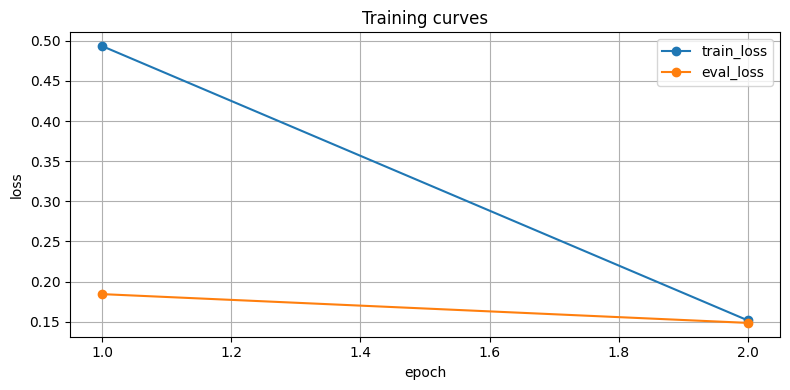

Saved: artifacts\training_curves.png


In [28]:
plt.figure(figsize=(8, 4))

if "loss" in history_df.columns:
    train_loss_df = history_df.dropna(subset=["loss"])
    plt.plot(train_loss_df["epoch"], train_loss_df["loss"], marker="o", label="train_loss")

if "eval_loss" in history_df.columns:
    eval_loss_df = history_df.dropna(subset=["eval_loss"])
    plt.plot(eval_loss_df["epoch"], eval_loss_df["eval_loss"], marker="o", label="eval_loss")

plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Training curves")
plt.legend()
plt.grid(True)
plt.tight_layout()

training_curves_path = ARTIFACTS_DIR / "training_curves.png"
plt.savefig(training_curves_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", training_curves_path)

## 10. Финальная оценка на validation и test

После обучения отдельно оцениваем лучший вариант модели на `validation`
и один раз на `test`.

In [29]:
# В некоторых версиях transformers callback для notebook может мешать evaluate() после train().
try:
    from transformers.utils.notebook import NotebookProgressCallback
    trainer.remove_callback(NotebookProgressCallback)
except Exception:
    pass

In [30]:
val_metrics = trainer.evaluate(tokenized_datasets["validation"])
print("Validation metrics:")
val_metrics

c:\Users\Anna\OneDrive\Desktop\courses\Ix3_course\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Validation metrics:


{'eval_loss': 0.14846138656139374,
 'eval_accuracy': 0.94,
 'eval_f1_macro': 0.914433696779926,
 'eval_runtime': 32.5973,
 'eval_samples_per_second': 61.355,
 'eval_steps_per_second': 3.835,
 'epoch': 2.0}

In [31]:
test_metrics = trainer.evaluate(tokenized_datasets["test"])
print("Test metrics:")
test_metrics

c:\Users\Anna\OneDrive\Desktop\courses\Ix3_course\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Test metrics:


{'eval_loss': 0.18205074965953827,
 'eval_accuracy': 0.9245,
 'eval_f1_macro': 0.8767565576288069,
 'eval_runtime': 33.8857,
 'eval_samples_per_second': 59.022,
 'eval_steps_per_second': 3.689,
 'epoch': 2.0}

In [32]:
print("Final test accuracy:", round(test_metrics["eval_accuracy"], 4))
print("Final test f1_macro:", round(test_metrics["eval_f1_macro"], 4))

Final test accuracy: 0.9245
Final test f1_macro: 0.8768


## 11. Детальные предсказания на test и матрица ошибок

Теперь получим предсказания на test-части,
сохраним примеры в `sample_predictions.csv`
и построим confusion matrix.

In [33]:
test_output = trainer.predict(tokenized_datasets["test"])

test_logits = test_output.predictions
test_preds = np.argmax(test_logits, axis=-1)
test_true = test_output.label_ids
test_probs = torch.softmax(torch.tensor(test_logits), dim=-1).numpy()
test_conf = test_probs.max(axis=1)

c:\Users\Anna\OneDrive\Desktop\courses\Ix3_course\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [34]:
test_texts = dataset_dict["test"]["text"]

predictions_df = pd.DataFrame(
    {
        "text": test_texts,
        "true_label": [label_names[i] for i in test_true],
        "pred_label": [label_names[i] for i in test_preds],
        "confidence": test_conf,
    }
)

predictions_df.head(10)

,text,true_label,pred_label,confidence
0,im feeling rather rotten so im not very ambiti...,sadness,sadness,0.996960
1,im updating my blog because i feel shitty,sadness,sadness,0.997480
2,i never make her separate from me because i do...,sadness,sadness,0.997486
3,i left with my bouquet of red and yellow tulip...,joy,joy,0.997205
4,i was feeling a little vain when i did this one,sadness,sadness,0.997389
5,i cant walk into a shop anywhere where i do no...,fear,fear,0.994262
6,i felt anger when at the end of a telephone call,anger,anger,0.992968
7,i explain why i clung to a relationship with a...,joy,joy,0.922613
8,i like to have the same breathless feeling as ...,joy,joy,0.996876
9,i jest i feel grumpy tired and pre menstrual w...,anger,anger,0.994478


In [35]:
# Сохраняем sample_predictions.csv
sample_predictions_path = ARTIFACTS_DIR / "sample_predictions.csv"
predictions_df.head(50).to_csv(sample_predictions_path, index=False, encoding="utf-8")

print("Saved:", sample_predictions_path)

Saved: artifacts\sample_predictions.csv


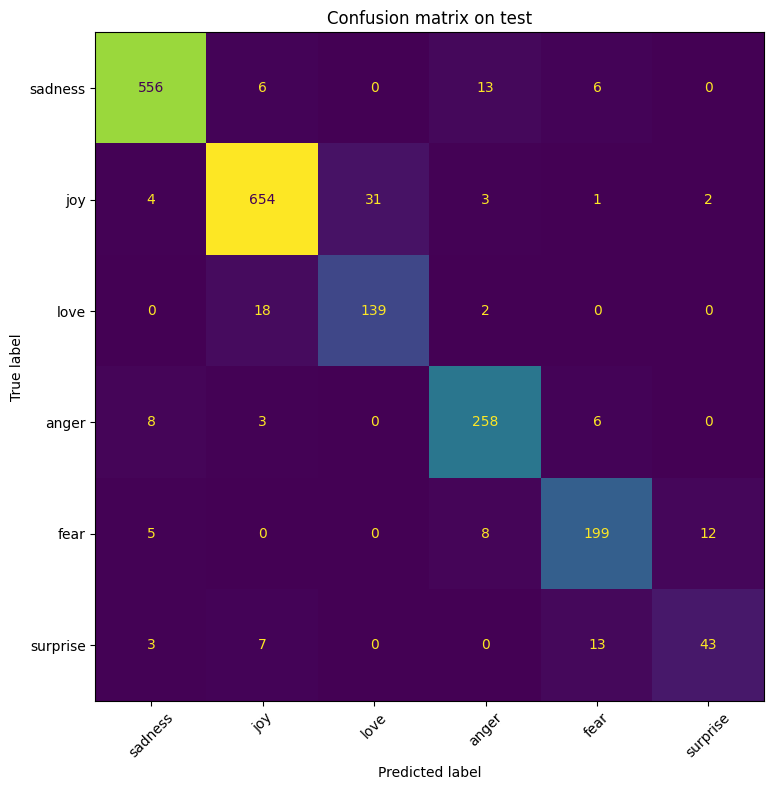

Saved: artifacts\confusion_matrix.png


In [36]:
# Матрица ошибок.
cm = confusion_matrix(test_true, test_preds)

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Confusion matrix on test")
plt.tight_layout()

confusion_matrix_path = ARTIFACTS_DIR / "confusion_matrix.png"
plt.savefig(confusion_matrix_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", confusion_matrix_path)

In [37]:
# Показываем 10 примеров предсказаний.
predictions_df.sample(10, random_state=42)

,text,true_label,pred_label,confidence
1860,i feel so dirty but after spending a day at th...,sadness,sadness,0.996319
353,i could feel his breath on me and smell the sw...,joy,love,0.891028
1333,i just want to feel loved by you,love,love,0.974045
905,i have felt the need to write out my sometimes...,anger,fear,0.822712
1289,at a party i met a girl who drew me to her,anger,fear,0.697686
1273,i feel this strange sort of liberation,surprise,fear,0.773690
938,i remember feeling thrilled to use my nursing ...,joy,joy,0.996987
1731,i always feel sympathetic for those that do as...,love,love,0.984476
65,i feel a little stunned but can t imagine what...,surprise,surprise,0.963122
1323,i feel slytherin is my house slytherin is for ...,joy,joy,0.906742


In [38]:
# Ошибки модели.
errors_df = predictions_df[predictions_df["true_label"] != predictions_df["pred_label"]].copy()
errors_df = errors_df.sort_values("confidence", ascending=False)

print("Number of errors:", len(errors_df))
errors_df.head(10)

Number of errors: 151


,text,true_label,pred_label,confidence
816,whenever i put myself in others shoes and try ...,anger,joy,0.997250
1533,i actually was in a meeting last week where so...,anger,sadness,0.996921
1270,i feel very saddened that the king whom i once...,joy,sadness,0.996167
1146,i feel affirmed gracious sensuous and will hav...,love,joy,0.993636
1928,i feel inside cause life is like a game someti...,fear,sadness,0.992897
1431,i felt a stronger wish to be free from self ch...,sadness,joy,0.992856
1253,i don t feel betrayed coz the backstabber had ...,surprise,sadness,0.988945
660,i was playing a sport in an advanced pe class ...,anger,joy,0.985234
1837,i hate these feelings in my heart i hate that ...,sadness,anger,0.984010
1440,i guess no matter how much i think im feeling ...,joy,fear,0.983572


## 12. Краткий анализ ошибок

Ниже интерпретируем несколько ошибок модели.
Нас интересуют не все ошибки подряд, а типичные случаи:
- близкие по смыслу эмоции;
- короткие и неоднозначные тексты;
- тексты, где эмоция выражена не напрямую, а косвенно.

In [39]:
# Выведем несколько ошибочных примеров текстом.
for i, row in errors_df.head(5).iterrows():
    print("=" * 120)
    print("TEXT:", row["text"])
    print("TRUE:", row["true_label"])
    print("PRED:", row["pred_label"])
    print("CONFIDENCE:", round(row["confidence"], 4))

TEXT: whenever i put myself in others shoes and try to make the person happy
TRUE: anger
PRED: joy
CONFIDENCE: 0.9972
TEXT: i actually was in a meeting last week where someone yelled at an older lady because her phone rang i felt terrible for her your boss treats you unfairly or in this case someone makes you feel you are not worth anything is only allowing those who offended to steal your joy
TRUE: anger
PRED: sadness
CONFIDENCE: 0.9969
TEXT: i feel very saddened that the king whom i once quite respected as far as monarchs go was ineffectual at best
TRUE: joy
PRED: sadness
CONFIDENCE: 0.9962
TEXT: i feel affirmed gracious sensuous and will have less self doubt when a href http generations
TRUE: love
PRED: joy
CONFIDENCE: 0.9936
TEXT: i feel inside cause life is like a game sometimes but then you came around me the walls just disappeared nothing to surround me and keep me from my fears im unprotected see how ive opened up youve made me trust
TRUE: fear
PRED: sadness
CONFIDENCE: 0.9929


Краткий комментарий по ошибкам:

1. Часть ошибок связана с тем, что некоторые эмоции семантически близки.
   Например, модель может путать `sadness` и `fear`, если текст выражает общий негативный эмоциональный фон.

2. На коротких текстах контекста мало,
   поэтому модель опирается на отдельные слова-маркеры и может ошибаться.

3. На пограничных примерах эмоция может быть выражена косвенно,
   без явного эмоционального слова,
   из-за чего предсказание становится менее устойчивым.